<div class="alert alert-block alert-info">
The purpose of this exercise it to build a picture of wealth and revenue distribution across France's counties (Departements)
This exercise will allow us to practice all every aspect of Exploratory Data Analysis.
</div>

In [17]:
#Data Collection
#import necessary libraries

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import io
import requests as rq
import zipfile
import plotly.io as pio
import streamlit as st
pio.renderers.default = "svg" # or "png"

from IPython.core.pylabtools import figsize
from matplotlib.pyplot import twinx

#Items to query the data source without using the website
download_url='https://www.insee.fr/fr/statistiques/fichier/5055909/BASE_TD_FILO_DEC_IRIS_2018.zip'
referer_url='https://data.europa.eu/'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
    "Referer": referer_url,
    "Accept":"*/*"}

#As there are several files compiled in the ZIP package, we select the csv file whose name does not include 'meta'
response = rq.get(download_url, headers=headers, stream=True)
if response.status_code == 200:
   with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        csv_file = [f for f in zf.namelist() if f.endswith('.csv')]
        data_file = [f for f in zf.namelist() if 'meta' not in f.lower()][0]
        with zf.open(data_file) as f:
            df_raw=pd.read_csv(f,sep=';')
            print ('File accessed- Dataframe created successfully.')
else:
    print (f'Still failing. status: {response.status_code}')

#Items to query the website for the list of Department names
download_url_names='https://www.regions-et-departements.fr/docs/departements-francais.xlsx'
response_2 = rq.get(download_url_names)
if response_2.status_code == 200:
    df_names=pd.read_excel(io.BytesIO(response_2.content))
    print ('Excel file accessed- Dataframe created successfully.')
else:
    print (f'Still failing. status: {response.status_code}')

#Formating the dataframe listing the county names
df_names.drop (['Unnamed: 2', 'Unnamed: 3','Unnamed: 4','Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],axis=1,inplace=True)
df_names.drop ([0,1],axis=0,inplace=True)
headers=['DEPT','DEPT_name']
df_names.columns=headers

#Ensure that all the county codes with 2 digits start with a zero.
df_names['DEPT']=df_names['DEPT'].astype(str).str.zfill(2)

#Ensure that the county code column also accomodates for 3-digit long codes
df_names['DEPT']=df_names['DEPT'].astype(str).apply(lambda x: x[:3] if x.startswith('97')else x[:2])
print (df_names.info())

File accessed- Dataframe created successfully.
Excel file accessed- Dataframe created successfully.
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 2 to 102
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DEPT       101 non-null    str  
 1   DEPT_name  101 non-null    str  
dtypes: str(2)
memory usage: 2.8 KB
None


In [18]:
#data preparation
print (df_raw['DEC_NOTE18'].value_counts())

DEC_NOTE18
0    12262
1      132
5        1
Name: count, dtype: int64


In [19]:
#Remove the fields that are not necessary.
df_cleaned = df_raw.drop(['DEC_TP6018','DEC_Q118','DEC_MED18','DEC_Q318','DEC_EQ18','DEC_D118','DEC_D218','DEC_D318','DEC_D418','DEC_D618','DEC_D718','DEC_D818','DEC_D918','DEC_RD18','DEC_S80S2018','DEC_NOTE18'],axis=1)

#County codes rules:
# Mainland France's county codes are two-digit long and range from 01 to 95.
# Corsica's county codes are a mix of alpha and numerical characters : 2A and 2B.
# French overseas territories are three-digit long and range from 972 to 988.

#I could not think of a single approach to extract the county codes from the IRIS codes. I decided to break up the main dataset in three subsets (one for main land, one for corsica and one for the overseas territories) in order to use different filtering methods. Once the three subsets are created, we group the records in each one of the subsets. Finally, we combine the three subsets into a main one that will be used for visualisation.

#isolate the alphanumeric county codes (2A and 2B) from main dataframe to a dedicated dataframe
df_temp = df_cleaned
df_temp['DEPT']=df_temp['IRIS'].str[:3]
filtering_corsica=('2A','2B')
df_temp = df_temp[df_temp['DEPT'].str.startswith(filtering_corsica)]
#print (df_temp.info())
df_corsica=df_temp
del df_temp

#remove the alphanumeric county codes
df_temp=df_cleaned
df_temp['DEPT']=df_temp['IRIS'].str[:3]
df_filtered=df_temp[~df_temp['IRIS'].str.startswith(('2A', '2B'))].copy()

#By changing the county code to numeric, I am able to retrieve the counties with three-digit and two-digit codes:
df_filtered ['DEPT']= df_filtered['DEPT'].astype('int16')
df_overseas=df_filtered[df_filtered['DEPT']>=970]
df_mainland=df_filtered[df_filtered['DEPT']<=959]

#This steps consists in formatting the DEPT codes
# - Remove the last digit for codes 01 to 95 and for codes 2A and 2B
# - Change the nature of the DEPT variable to allow some padding for DEPT Codes 01 to 09

df_mainland['DEPT']=df_mainland['DEPT']//10
df_mainland['DEPT']=df_mainland['DEPT'].astype(str).str.zfill(2)
df_corsica['DEPT']=df_corsica['DEPT'].str[:2]

In [20]:
#Cheching the number of missing values.
print (df_corsica.isnull().sum())

IRIS          0
DEC_PIMP18    1
DEC_GI18      0
DEC_PACT18    0
DEC_PTSA18    0
DEC_PCHO18    0
DEC_PBEN18    0
DEC_PPEN18    0
DEC_PAUT18    0
DEPT          0
dtype: int64


One null value in the whole dataframe.
Since, the records will be amalgamated per county, the null value will have a limited impact on the outcome.
I choose to ignore the null value and proceed ahead.

In [21]:
#Grouping the data per county code and getting the average data per county:
cols_to_mean=['DEC_GI18','DEC_PIMP18','DEC_PACT18','DEC_PTSA18','DEC_PCHO18','DEC_PPEN18','DEC_PBEN18','DEC_PAUT18']
result_corsica=df_corsica.groupby('DEPT')[cols_to_mean].mean().reset_index()
result_mainland=df_mainland.groupby('DEPT')[cols_to_mean].mean().reset_index()
result_overseas=df_overseas.groupby('DEPT')[cols_to_mean].mean().reset_index()

#Rounding the data.
result_corsica=result_corsica.round(2)
result_mainland=result_mainland.round(2)
result_overseas=result_overseas.round(2)

#Merge all the subsets into one dataframe
df_final = pd.concat([result_corsica, result_mainland, result_overseas])
df_final['DEPT_proc']=df_final['DEPT'].astype(str).str.zfill(3)
df_names['DEPT']=df_names['DEPT'].astype(str).str.zfill(3)

#Merge the Dept names to the df_final dataframe
df_final=df_final.merge(df_names[['DEPT','DEPT_name']],left_on='DEPT_proc',right_on='DEPT', how='left')

#Let's remove the unnecessary columns:
df_final_cleaned = df_final.drop(['DEPT_proc', 'DEPT_y'], axis=1)

df_final=df_final_cleaned

<div class="alert alert-block alert-info">
The data is now ready to be visualized.
I decided to use several techniques of data visualization:

- Plotly express
- Matplotlib
- Choropleth map
- Interactive dashboard using Dash
</div>

<Figure size 640x480 with 0 Axes>

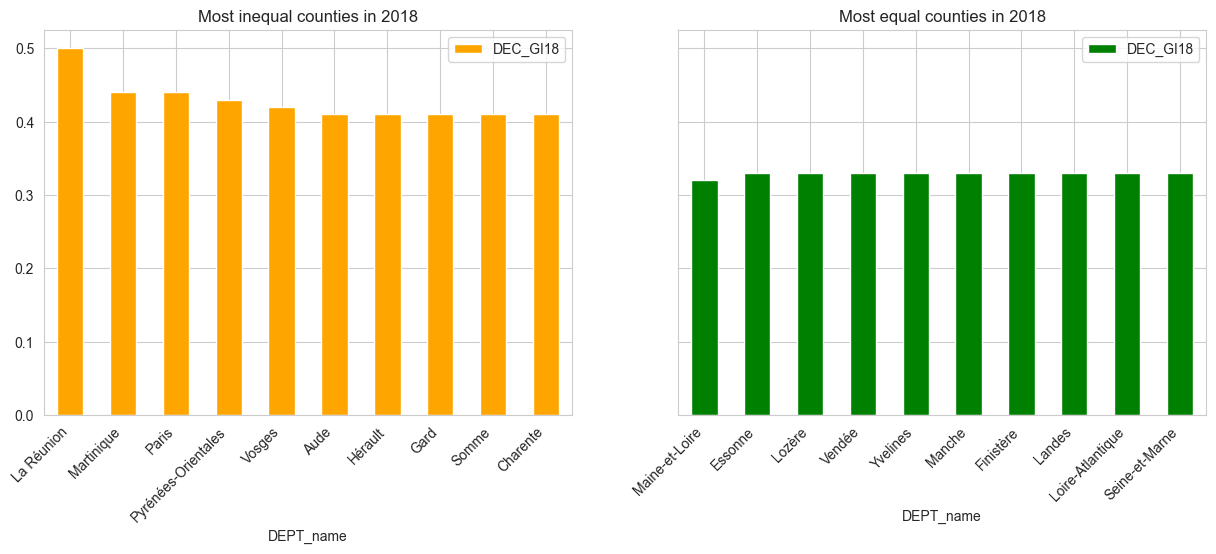

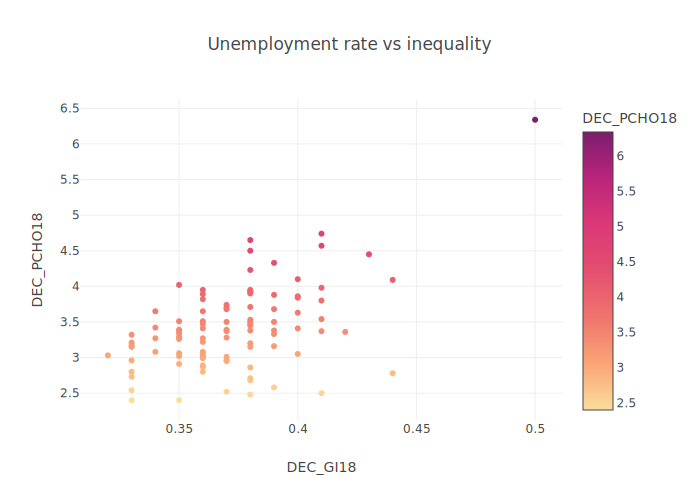

In [22]:
#Visualizing the data
import plotly.express as px

#Using matplotlib to produce a chart comprising 2 subplots
fig=plt.figure()
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

#subplot#1
df_final.sort_values(by="DEC_GI18",ascending=False,axis=0,inplace=True)
df_gini=df_final[['DEPT_x','DEPT_name','DEC_GI18']].head(10)
df_gini.plot(kind='bar',x='DEPT_name',y='DEC_GI18',color='orange',ax=ax0)
ax0.set_title('Most inequal counties in 2018')
ax0.set_xlabel='counties'
ax0.set_xticklabels(ax0.get_xticklabels(),rotation=45,ha='right')
ax0.set_ylabel='Gini index'

#subplot#2
df_final.sort_values(by="DEC_GI18",ascending=True,axis=0,inplace=True)
df_gini_bttm=df_final[['DEPT_x','DEPT_name','DEC_GI18']].head(10)
df_gini_bttm.plot(kind='bar',x='DEPT_name',y='DEC_GI18',color='green',ax=ax1)
ax1.set_title('Most equal counties in 2018')
ax1.set_xlabel='counties'
ax1.set_xticklabels(ax1.get_xticklabels(),rotation=45,ha='right')
ax1.set_ylabel='Gini index'

plt.show()

#scatter plot visualizing unemployment and inequality using plotly express
df_fig_2=df_final[['DEPT_name','DEC_GI18', 'DEC_PCHO18']]
#print(df_fig_2.head(15))
Fig_2=px.scatter(
    df_fig_2,
    x='DEC_GI18',
    y='DEC_PCHO18',
    title='Unemployment rate vs inequality',
    color='DEC_PCHO18',
    color_continuous_scale='sunsetdark',
    hover_name='DEPT_name',
)
Fig_2.show()

<div class="alert alert-block alert-info">
Regarding the top bar charts: We observe that the inequality is limited to values ranging from 0.32 to 0.50. The average index for France, in 2018 was 0.32. Slightly above the EU average standing at 0.29.

2 of the top 10 inequal counties are overseas territories.
The top 10 equal counties have an index of 0.32 or 0.33.

There seems to be a light correlation. The counties with the highest Inequality index are also the one with the highest proportion of unemployment recipients. The lower the number of unemployment benefits, the lower the inequality index.
</div>

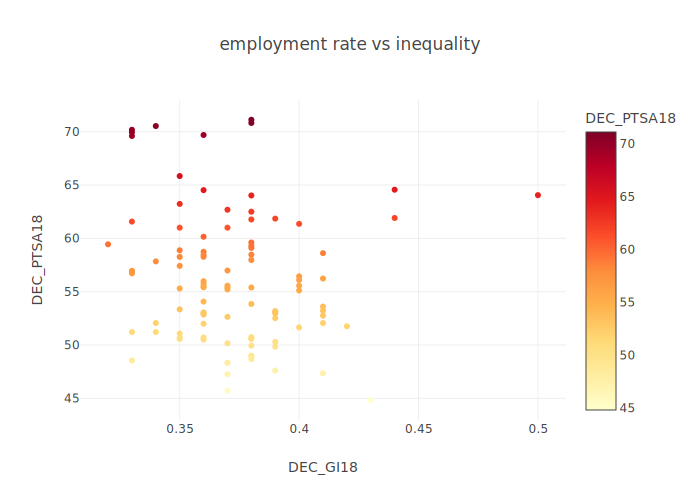

In [23]:
#scatter plot visualizing the correlation between employment and inequality

df_fig_3=df_final[['DEPT_x', 'DEC_GI18', 'DEC_PTSA18', 'DEPT_name']]
Fig_3=px.scatter(
    df_fig_3,
    x='DEC_GI18',
    y='DEC_PTSA18',
    title='employment rate vs inequality',
    color='DEC_PTSA18',
    hover_name='DEPT_name',
    color_continuous_scale=px.colors.sequential.YlOrRd,
)
Fig_3.show()

<div class="alert alert-block alert-info">
This graph comes to nuance the previous diagram. Although the trend is respected in that counties with the biggest number of employed population seem to have a lower inequality index, there are more factor to explain the inequality index. Counties such as La Réunion show a high rate of employment and yet score badly in terms of inequality.

Let's create a choropleth showing the unemployment rates in every county
</div>

In [24]:
#We need to retrieve the GEOJson file with all the counties' coordinates.
import json
import requests as rq

#Items to query the website for the GEOJson file
download_url_GEO='https://static.data.gouv.fr/resources/contours-des-communes-de-france-simplifie-avec-regions-et-departement-doutre-mer-rapproches/20210523-142601/a-dep2021.json'
response_2 = rq.get(download_url_GEO)
if response_2.status_code == 200:
   geojson_data = response_2.json()
   print ('GEOJson file accessed- Dictionary created successfully.')
else:
    print (f'Still failing. status: {response.status_code}')
print (geojson_data['features'][0]['properties'])


GEOJson file accessed- Dictionary created successfully.
{'dep': '01', 'reg': '84', 'libgeo': 'Ain'}


In [25]:
#Creating the heatmap
fig = px.choropleth(
    df_final,
    geojson=geojson_data,
    locations='DEPT_x',
    featureidkey="properties.dep",
    color='DEC_GI18',
    hover_name='DEPT_name',
    hover_data={
        'DEPT_x': True,
        'DEC_GI18': ':.3f',
    },
    color_continuous_scale="rdylgn_r",
    range_color=(0.3, 0.5),
    scope="europe",
    labels={'DEC_GI18': 'Gini Index'}
)

# This command zooms the map automatically to fit your data (France)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(width=900, height=600)
fig.update_traces(hoverinfo="all", selector=dict(type='choropleth'))
fig.show()

print("DataFrame Sample:", df_final['DEPT_x'].iloc[0])
print("GeoJSON Sample:", geojson_data['features'][0]['properties']['dep'])


DataFrame Sample: 49
GeoJSON Sample: 01


<div class="alert alert-block alert-info">
We want to create a dashboard allowing us to view the statistics for a particular county.
</div>

In [26]:
#importing the required libbraries
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import seaborn as sns
import pandas as pd

app = Dash(__name__)

# Pre-calculate the country average once
country_avg = df_final['DEC_PIMP18'].mean()
df_sorted = df_final.sort_values('DEPT_name')
app.layout = html.Div([
    html.H1("Income Distribution Dashboard",style = {'textAlign': 'center','fontFamily': 'Trebuchet MS, sans-serif'}),

    # Dropdown: Display Name, but value is the Code
    html.Div([
        html.Label("Select a County:",style = {'fontFamily': 'Trebuchet MS, sans-serif'}),
        dcc.Dropdown(
            id='dept-dropdown',
            options=[{'label': row['DEPT_name'], 'value': row['DEPT_x']} for _, row in df_sorted.iterrows()],
            value=df_sorted['DEPT_x'].iloc[0],
            clearable=False,
            style = {'fontFamily': 'Trebuchet MS, sans-serif'}
        ),
    ], style={'width': '30%', 'padding': '20px'}),

    # Row 1: Column Chart
    html.Div([
        dcc.Graph(id='bar-chart')
    ],style={'display': 'inline-block', 'width': '48%'}),

    # Row 2: Pie Chart
    html.Div([
        dcc.Graph(id='pie-chart')
    ],style={'display': 'inline-block', 'width': '48%'}),
])

# Callback to update both charts based on selection
@app.callback(
    [Output('bar-chart', 'figure'),
     Output('pie-chart', 'figure')],
    [Input('dept-dropdown', 'value')]
)
def update_charts(selected_dept):
    # Filter data for selected department
    filtered_df = df_final[df_final['DEPT_x'] == selected_dept].iloc[0]

    # 1. Bar Chart: Selected Dept vs Country Avg
    bar_fig = px.bar(
        x=[filtered_df['DEPT_name'], 'Country Average'],
        y=[filtered_df['DEC_PIMP18'], country_avg],
        title=f"Taxable Income Share (PIMP18): {filtered_df['DEPT_name']} vs National",
        labels={'x': 'Entity', 'y': 'Percentage'},
        color=['Selected', 'Average'],
        color_discrete_sequence=px.colors.qualitative.Pastel
    )

    # 2. Pie Chart: Breakdown of Income Types
    income_labels = ['Salaries', 'Unemployment', 'Benefits', 'Pensions', 'Other']
    income_values = [
        filtered_df['DEC_PTSA18'],
        filtered_df['DEC_PCHO18'],
        filtered_df['DEC_PBEN18'],
        filtered_df['DEC_PPEN18'],
        filtered_df['DEC_PAUT18']
    ]

    pie_fig = px.pie(
        names=income_labels,
        values=income_values,
        hole=0.4,
        title=f"Income Source Distribution: {filtered_df['DEPT_name']}",
        color_discrete_sequence=px.colors.sequential.Agsunset
    )
    bar_fig.update_layout(template='plotly')
    pie_fig.update_layout(template='plotly')
    return bar_fig, pie_fig

if __name__ == '__main__':
    app.run(debug=True)

<div class="alert alert-block alert-info">
This conlcudes this jupyter Notebook exercise allowing us to work on the different aspects of data analysis.

Thank you!
</div>